<a href="https://colab.research.google.com/github/jaredlan1/getting_started_with_ML/blob/main/Exam1_question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [30]:
class PINN(nn.Module):
  def __init__(self, width=20):
      super().__init__()
      self.net = nn.Sequential(
          nn.Linear(1, width),
          nn.Tanh(),
          nn.Linear(width, width),
          nn.Tanh(),
          nn.Linear(width,1)

      )

  def forward(self, x):
      return self.net(x)


model = PINN().to(device)

In [40]:
x0 = 0.0
x1 = 5.0
N_f= 2000
x_f= torch.rand(N_f, 1 , device=device)*(x1-x0)+x0
x_f.requires_grad_(True)


tensor([[2.5609],
        [0.8591],
        [4.1878],
        ...,
        [4.4593],
        [4.2814],
        [4.8085]], requires_grad=True)

In [41]:
x_b0= torch.tensor([[x0]], device=device, requires_grad=True)
x_b1= torch.tensor([[x1]], device=device, requires_grad=True)
y_b0= torch.tensor([[1.0]], device=device)
y_b1= torch.tensor([[0.0]], device=device)

In [42]:
def grad(outputs, inputs):
  return torch.autograd.grad(outputs,inputs,
      grad_outputs = torch.ones_like(outputs), create_graph=True, retain_graph=True)[0]

In [43]:
mse = nn.MSELoss()

In [44]:
def pinn_loss():
  y = model(x_f)
  y_x = grad(y, x_f)
  y_xx = grad(y_x, x_f)

  residual= y_xx-2.0*y_x + y-torch.cos(x_f)
  loss_pde= mse(residual, torch.zeros_like(residual))


  y_0pred = model(x_b0)
  y1_pred =model(x_b1)

  loss_bc= mse(y_0pred, y_b0) + mse(y1_pred, y_b1)
  return loss_pde +loss_bc, loss_pde.detach(), loss_bc.detach()


In [45]:
adam= optim.Adam(model.parameters(), lr=1e-3)

In [46]:
epocs = 6000
for epoc in range(1, epocs + 1):
    adam.zero_grad()
    loss, lpde, lbc = pinn_loss()
    loss.backward()
    adam.step()



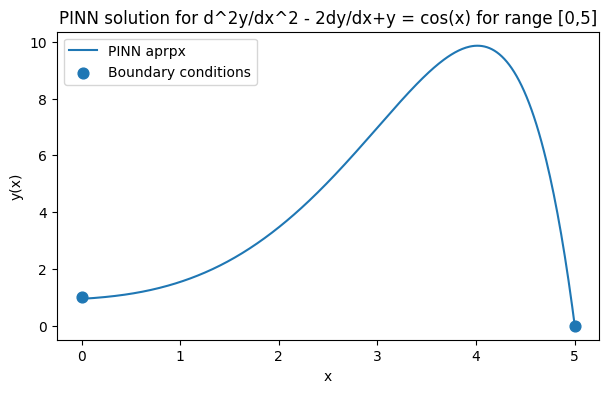

In [50]:
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(x0, x1, 400, device=device).view(-1, 1)
    y_plot = model(x_plot).cpu().numpy()
    x_plot_cpu = x_plot.cpu().numpy()

plt.figure(figsize=(7,4))
plt.plot(x_plot_cpu, y_plot, label="PINN aprpx")
plt.scatter([0, 5], [1, 0], s=60, marker="o", label="Boundary conditions")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("PINN solution for d^2y/dx^2 - 2dy/dx+y = cos(x) for range [0,5]")
plt.legend()
plt.show()